# **EDA Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [1]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Mounted at /content/gdrive

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [3]:
# <Student to fill this section>
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

### 0.d Import Packages

In [4]:
# <Student to fill this section>
import pandas as pd
import altair as alt

---
## A. Project Description


In [5]:
# <Student to fill this section>
group_name = "Group 24"
student_name = "Yuyang Chen"
student_id = "13417454"

In [6]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [8]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Data Understanding

### B.1   Load Dataset

In [9]:
# Do not modify this code
try:
  df = pd.read_csv(folder_path / "customer_satisfaction.csv")
except Exception as e:
  print(e)

### B.2 Explore Dataset

> You can add more cells in this section

In [10]:
# display head
df.head()

,Unnamed: 0,customer_id,nps,cltv,reason
0,0,70f18737-5835-4639-be44-f1a8c6604490,4,2056,NaN
1,1,206e8726-2743-4739-8f2f-758e30256314,3,2916,NaN
2,2,40da1c87-0650-4378-b8d7-0a49cb21085c,4,5248,NaN
3,3,4e28bb69-cee2-4fdf-8831-28935bb5e9b6,3,4607,NaN
4,4,39c9339b-c22b-4bf2-8c73-deb7b6e02de1,4,3030,NaN


In [11]:
#display tail
df.tail()

,Unnamed: 0,customer_id,nps,cltv,reason
15769,15769,43f7e6fd-64e2-43e9-919f-3fea3522e544,3,4486,Poor expertise of online support
15770,15770,4909d875-a132-4a41-a092-6f98bcdcd26a,3,4933,NaN
15771,15771,141095c7-503a-428e-aac3-4107d8c8cd21,2,3735,Attitude of support person
15772,15772,5137f985-3356-4c43-b86c-9331c9d601b5,4,4057,NaN
15773,15773,d4719612-9b4e-4a34-8893-ddb81b3c6c83,3,5691,Network reliability


In [12]:
#display shape of dataframe
df.shape

(15774, 5)

In [13]:
#display info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15774 entries, 0 to 15773
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   15774 non-null  int64 
 1   customer_id  15774 non-null  object
 2   nps          15774 non-null  int64 
 3   cltv         15774 non-null  int64 
 4   reason       4189 non-null   object
dtypes: int64(3), object(2)
memory usage: 616.3+ KB


In [14]:
#display descriptive info
df.describe()

,Unnamed: 0,nps,cltv
count,15774.000000,15774.000000,15774.000000
mean,7886.500000,3.249525,4386.955750
std,4553.705908,1.201393,1191.571121
min,0.000000,1.000000,2003.000000
25%,3943.250000,3.000000,3424.000000
50%,7886.500000,3.000000,4539.000000
75%,11829.750000,4.000000,5362.750000
max,15773.000000,5.000000,6500.000000


In [15]:
#Find possible outliers
for col in ['nps', 'cltv']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_out = df[(df[col] <= lower) & (df[col] >= upper)]
    df_out.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   0 non-null      int64 
 1   customer_id  0 non-null      object
 2   nps          0 non-null      int64 
 3   cltv         0 non-null      int64 
 4   reason       0 non-null      object
dtypes: int64(3), object(2)
memory usage: 0.0+ bytes
<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   0 non-null      int64 
 1   customer_id  0 non-null      object
 2   nps          0 non-null      int64 
 3   cltv         0 non-null      int64 
 4   reason       0 non-null      object
dtypes: int64(3), object(2)
memory usage: 0.0+ bytes


In [16]:
# <Student to fill this section>
dataset_insights = """

  - Shape: 15,774 rows × 5 columns.
  - Columns: 'Unnamed: 0', 'customer_id', 'nps' , 'cltv', 'reason'.
  - NPS: Ranges 1–5; mean=3.25 (std=1.20), median=3. Skewed toward moderate scores (25th percentile=3, 75th=4).
  - CLTV: Mean=4,387 (std=1,192), min=2,003, max=6,500. Wide spread, suggesting high variability.
  - Unnamed: 0 is the index column. Drop.
  - 'reason' has significant missing values (only 4,189/15,774 entries populated).

"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.3 Explore Feature of Interest 1: NPS

> You can add more cells in this section

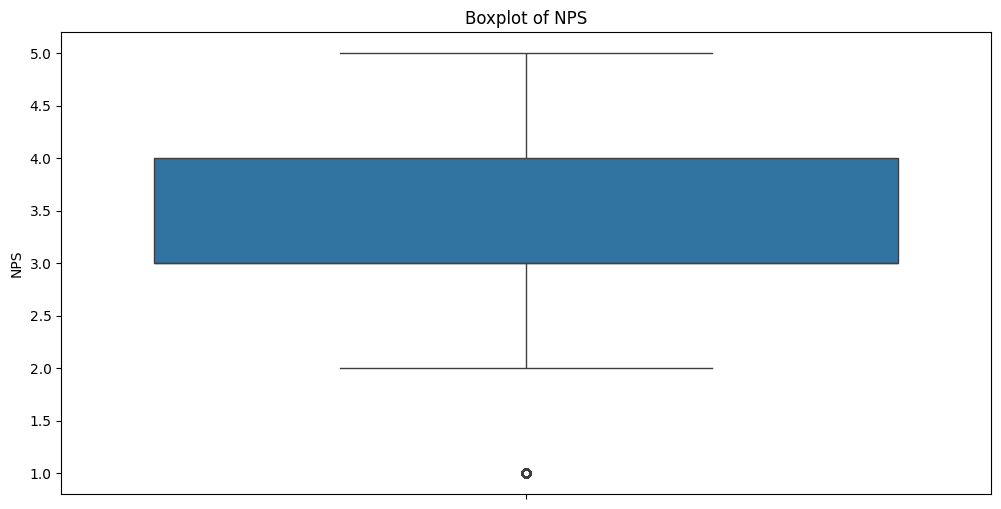

In [18]:
# Generate boxplots for NPS
plt.figure(figsize=(12, 6))
sns.boxplot(df['nps'])
plt.ylabel('NPS')
plt.title('Boxplot of NPS')
plt.show()

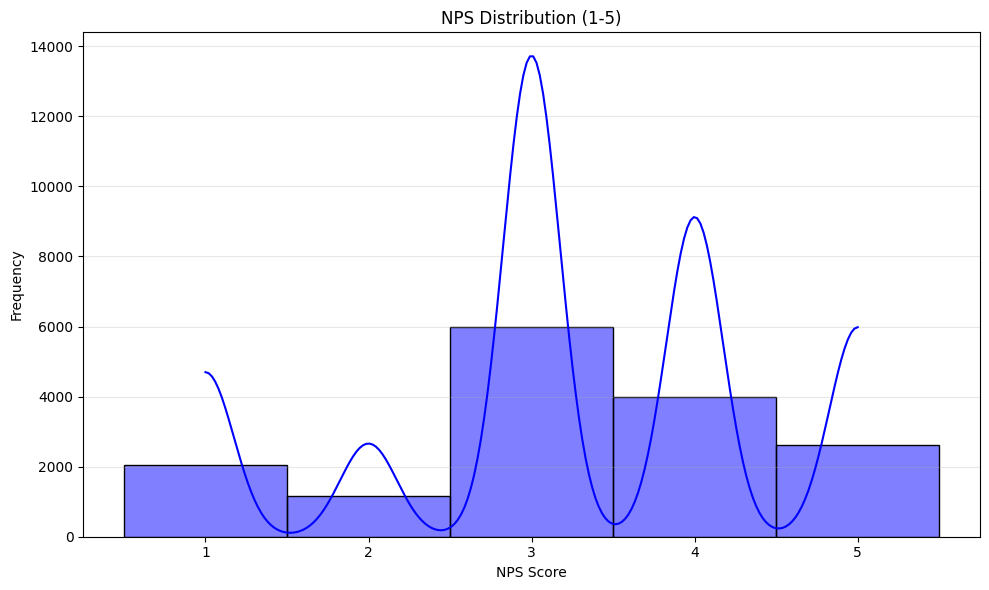

In [52]:
# NPS histogram
plt.figure(figsize=(10,6))
sns.histplot(df['nps'],
             bins=np.arange(0.5, 6.5, 1),
             kde=True,
             color='blue')
plt.xticks(range(1, 6))  #set int 1-5
plt.title('NPS Distribution (1-5)')
plt.xlabel('NPS Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# <Student to fill this section>
feature1_insights = """
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### B.4 Explore Feature of Interest 2: CLTV

> You can add more cells in this section

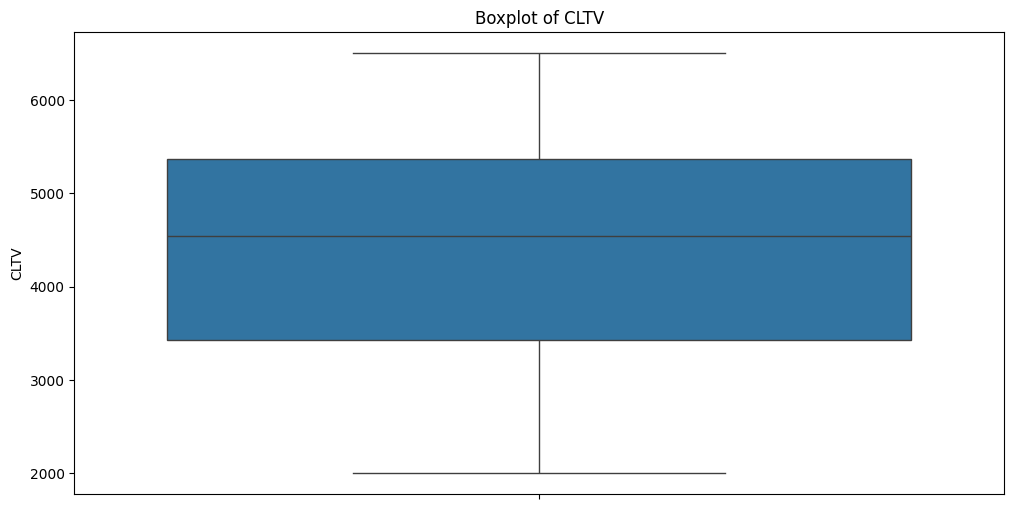

In [21]:
# Generate boxplots for cltv
plt.figure(figsize=(12, 6))
sns.boxplot(df['cltv'])
plt.ylabel('CLTV')
plt.title('Boxplot of CLTV')
plt.show()

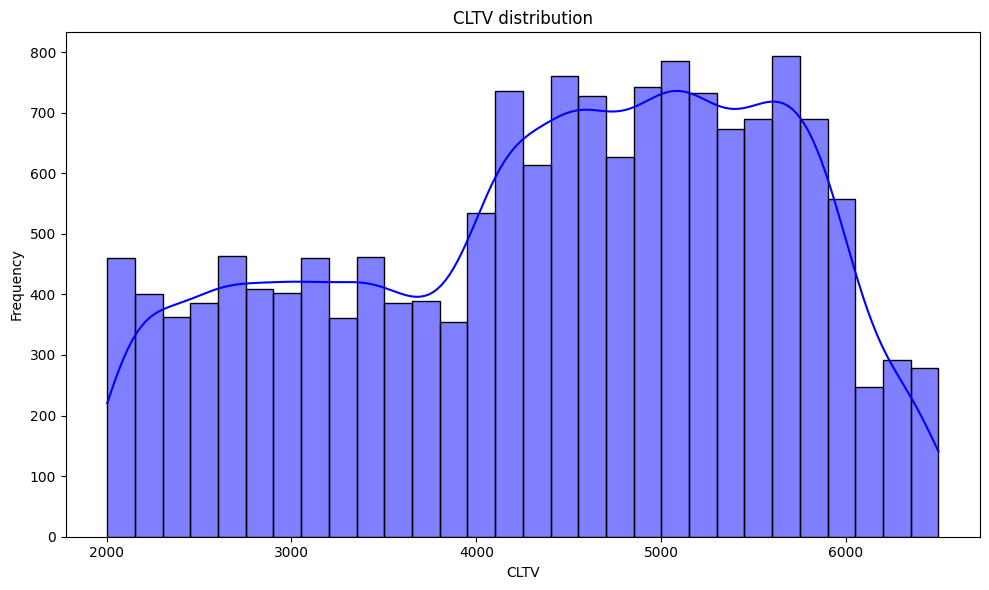

In [53]:
# cltv histogram
plt.figure(figsize=(10,6))
sns.histplot(df['cltv'], bins=30, kde=True, color='blue')
plt.title('CLTV distribution')
plt.xlabel('CLTV')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [23]:
# <Student to fill this section>
feature_2_insights = """
"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.5 Explore Feature of Interest n

> You can add more cells in this section

In [25]:
# <Student to fill this section>

In [26]:
# <Student to fill this section>
feature_n_insights = """
"""

In [27]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## C. Data Cleaning

### C.1 Copy Dataset

In [54]:
# Do not modify this code
df_clean = df.copy()
try:
  df_clean = df.copy()
except Exception as e:
  print(e)

### C.2 Handle Missing Values

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [56]:
# <Student to fill this section>
# Handle missing values
df_clean = df_clean.dropna(subset=['nps', 'cltv'])

In [58]:
# Display summary
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15774 entries, 0 to 15773
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   15774 non-null  int64 
 1   customer_id  15774 non-null  object
 2   nps          15774 non-null  int64 
 3   cltv         15774 non-null  int64 
 4   reason       4189 non-null   object
dtypes: int64(3), object(2)
memory usage: 616.3+ KB
None


In [30]:
# <Student to fill this section>
data_cleaning_1_explanations = """


"""

In [31]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### C.3 Drop irrelevant column

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [59]:
# drop redundant column
df_clean = df_clean.drop(columns=["Unnamed: 0"])

In [60]:
# drop duplicates
df_clean = df_clean.drop_duplicates()

In [61]:
# Display summary
print(df_clean.info())
print(df_clean.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 15771
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  7043 non-null   object
 1   nps          7043 non-null   int64 
 2   cltv         7043 non-null   int64 
 3   reason       1869 non-null   object
dtypes: int64(2), object(2)
memory usage: 275.1+ KB
None
               nps         cltv
count  7043.000000  7043.000000
mean      3.244924  4400.295755
std       1.201657  1183.057152
min       1.000000  2003.000000
25%       3.000000  3469.000000
50%       3.000000  4527.000000
75%       4.000000  5380.500000
max       5.000000  6500.000000


In [33]:
# <Student to fill this section>
data_cleaning_2_explanations = """

Dropping unnamed column for cleanliness. Drop duplicates if there are any.
"""

In [34]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### C.4 Fixing "\<describe_issue_here\>"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [35]:
# <Student to fill this section>

In [36]:
# <Student to fill this section>
data_cleaning_3_explanations = """
"""

In [37]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## D. Feature Engineering

### D.1 Copy Datasets

In [62]:
# Do not modify this code
try:
  df_eng = df_clean.copy()
except Exception as e:
  print(e)

### D.2 New Feature "Churned"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [67]:
# Create target variable (1 = churned, 0 = active)
df_eng['churned'] = np.where(df_eng['reason'].notnull(), 1, 0)
df_eng['churned'].value_counts()

,count
churned,
0,5174
1,1869


In [68]:
#display info
df_eng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 15771
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  7043 non-null   object
 1   nps          7043 non-null   int64 
 2   cltv         7043 non-null   int64 
 3   reason       1869 non-null   object
 4   churned      7043 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 330.1+ KB


In [70]:
# <Student to fill this section>
feature_engineering_1_explanations = """

!Assume customers who have not written reason for leaving as stay.¡

Create feature for easy classification on whether customer stay or leave.

"""

In [71]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### D.3 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [42]:
# <Student to fill this section>

In [43]:
# <Student to fill this section>
feature_engineering_2_explanations = """
"""

In [44]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### D.4 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [45]:
# <Student to fill this section>

In [46]:
# <Student to fill this section>
feature_engineering_3_explanations = """
"""

In [47]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

---
## E. Save Datasets

In [73]:
# save dataset to .csv
df_eng.to_csv('customer_satisfaction_clean.csv')